<a href="https://colab.research.google.com/github/asgharlaib/Clustering_and_Fitting/blob/main/arma_j_j_casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Notebook Metadata Cleanup

This cell will attempt to remove potentially corrupted widget metadata from this notebook file, which can sometimes cause issues when saving to platforms like GitHub. Please run this cell if you encounter 'invalid notebook' errors.

In [3]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from itertools import product
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 7.5]

#Data Loading and Visualisation

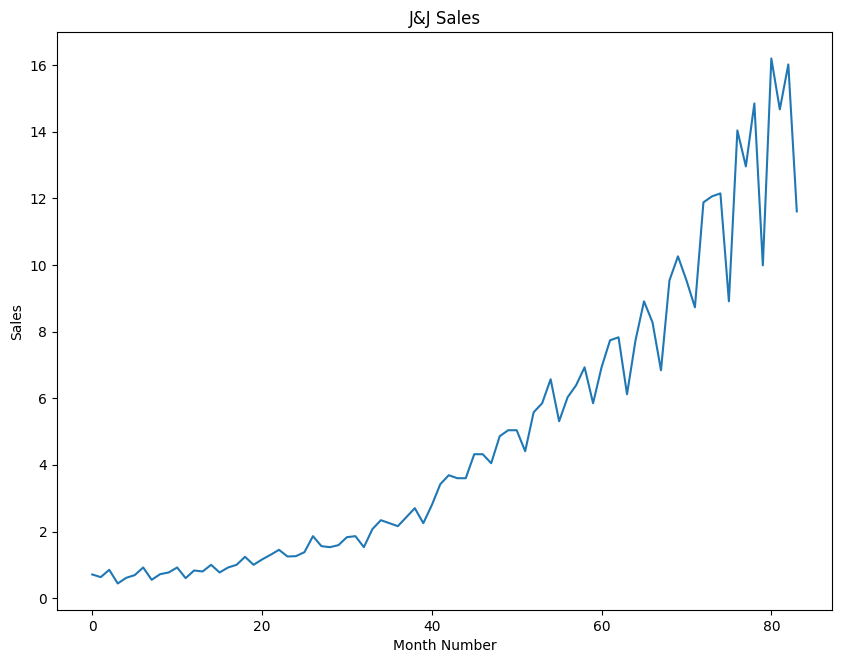

In [4]:
data = pd.read_csv('jj.csv')
data.head()

plt.figure()
plt.plot(data['data'])
plt.title("J&J Sales")
plt.xlabel("Month Number")
plt.ylabel("Sales")

plt.show()

#Autocorrelation and Partial Autocorrelation Graphs

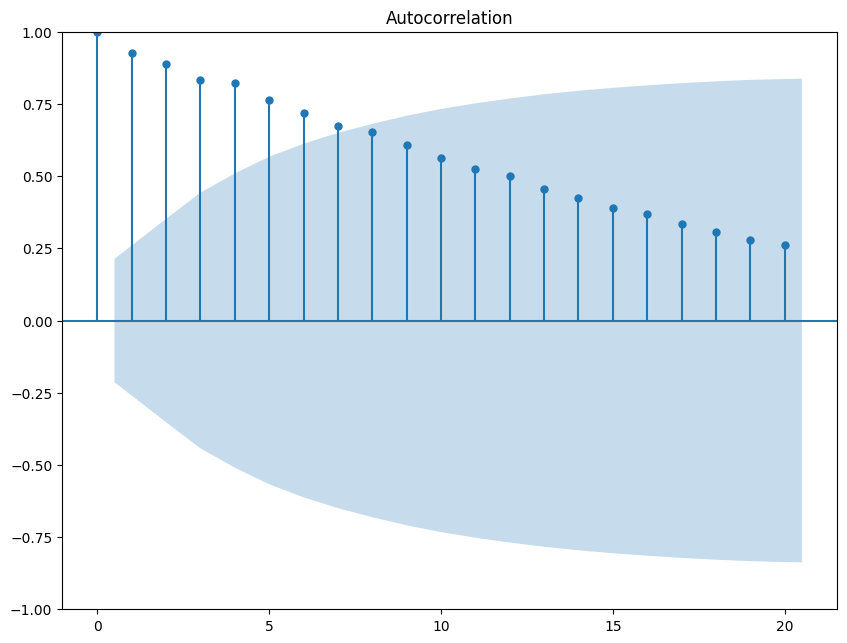

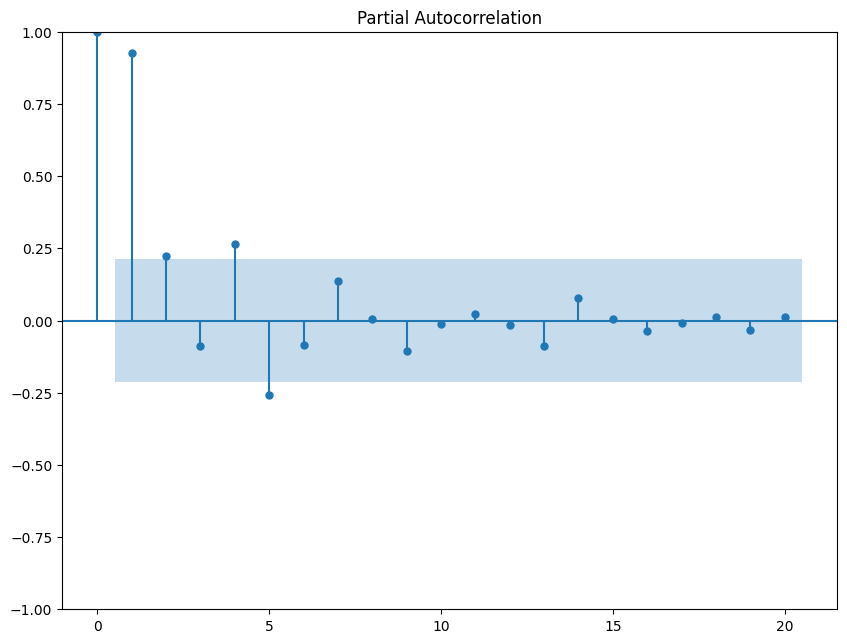

In [5]:
plot_acf(data['data'])
plot_pacf(data['data'])
plt.show()

#Testing and Processing Stationarity

In [6]:
adfuller_result = adfuller(data['data'])

print(f'Score = {adfuller_result[0]}')
print(f'P-value = {adfuller_result[1]}')

Score = 2.7420165734574744
P-value = 1.0


In [7]:
data['Log-Transformed'] = np.log(data['data'])
data['Data-Transformed'] = data['Log-Transformed'].diff()
data.head()

,date,data,Log-Transformed,Data-Transformed
0,1960-01-01,0.71,-0.342490,NaN
1,1960-04-01,0.63,-0.462035,-0.119545
2,1960-07-02,0.85,-0.162519,0.299517
3,1960-10-01,0.44,-0.820981,-0.658462
4,1961-01-01,0.61,-0.494296,0.326684


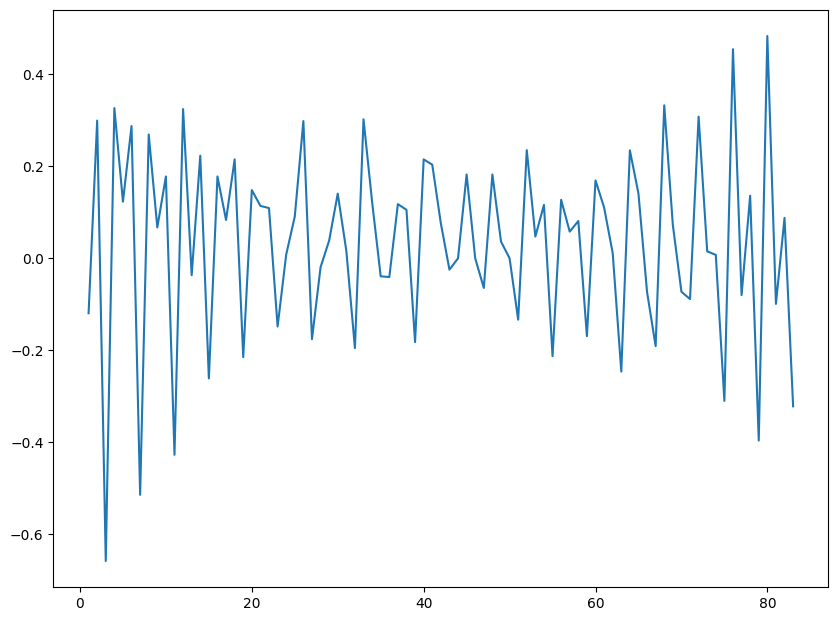

In [8]:
plt.figure()

plt.plot(data['Data-Transformed'])
plt.show()

In [9]:
adfuller_transformed_result = adfuller(data['Data-Transformed'][1:])

print(f'Statistic:{adfuller_transformed_result[0]}')
print(f'P-value:{adfuller_transformed_result[1]}')

Statistic:-4.317043945811837
P-value:0.00041497314044406584


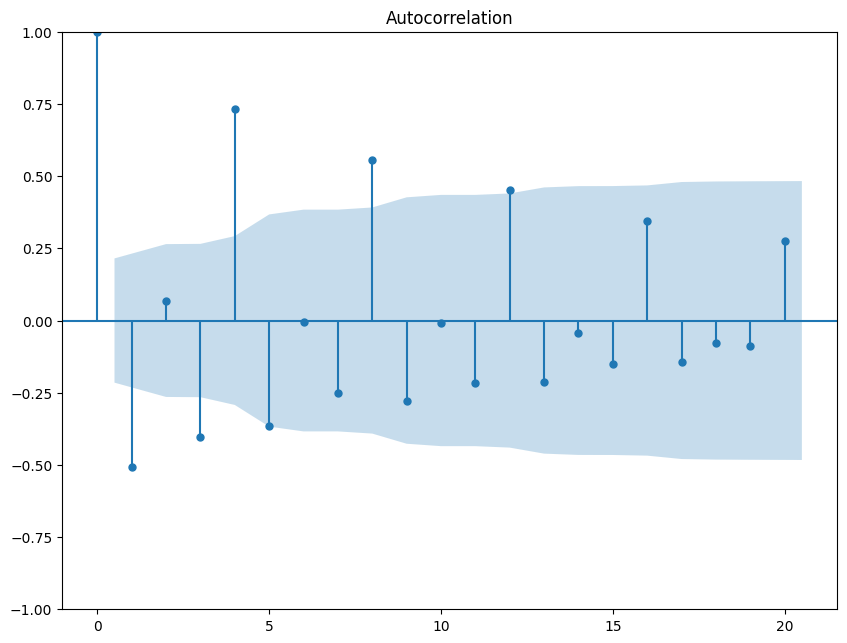

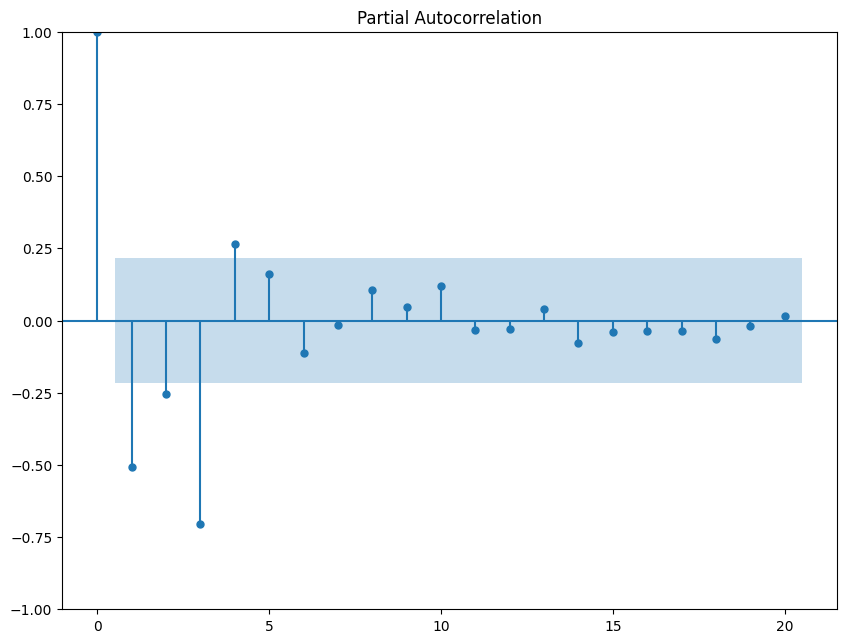

In [10]:
plot_acf(data['Data-Transformed'][1:])
plot_pacf(data['Data-Transformed'][1:])
plt.show()

#Modelling

ARIMA

In [11]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(data['data'], order=(3,1,3))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   data   No. Observations:                   84
Model:                 ARIMA(3, 1, 3)   Log Likelihood                 -76.286
Date:                Fri, 03 Jul 2026   AIC                            166.572
Time:                        19:36:28   BIC                            183.504
Sample:                             0   HQIC                           173.374
                                 - 84                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0311      0.036    -28.919      0.000      -1.101      -0.961
ar.L2         -1.0273      0.043    -23.890      0.000      -1.112      -0.943
ar.L3         -0.9768      0.030    -32.175      0.0

In [12]:
# I have used tqdm_notebook here to add a progress bar when the script is running

def optimize_ARIMA(endog, order_list):
    """
        Return dataframe with parameters and corresponding AIC

        order_list - list with (p, d, q) tuples
        endog - the observed variable, in this case data['data']
    """

    results = []

    for order in tqdm_notebook(order_list):
        try:
            #model = SARIMAX(endog, order=order, simple_differencing=False).fit(disp=False)
            model = ARIMA(endog, order=order)
            model_fit = model.fit()
        except:
            continue

        aic = model_fit.aic
        results.append([order, model_fit.aic])
        #print(order)
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p, d, q)', 'AIC']
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)

    return result_df

In [13]:
results = []

for p in range(0,8):
    for q in range(0,8):
        model = ARIMA(data['data'], order = (p,1,q))
        model_fit = model.fit()

        aic = model_fit.aic

        results.append(((p,1,q), model_fit.aic))

result_df = pd.DataFrame(results, columns=['(p,1,q)', 'AIC'])
result_df = result_df.sort_values(by='AIC', ascending = True).reset_index(drop=True)
print(result_df)

      (p,1,q)         AIC
0   (6, 1, 3)  115.423918
1   (4, 1, 6)  115.859267
2   (7, 1, 1)  116.050994
3   (5, 1, 3)  116.536248
4   (5, 1, 4)  117.242537
..        ...         ...
59  (0, 1, 1)  265.481216
60  (0, 1, 3)  265.497398
61  (1, 1, 0)  266.632563
62  (2, 1, 0)  267.751437
63  (0, 1, 0)  295.995493

[64 rows x 2 columns]


In [14]:
from statsmodels.tsa.arima.model import ARIMA

# p,d,q ARIMA Model
best_model = ARIMA(data['data'], order=(4,1,6))

best_model_fit = best_model.fit()
print(best_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   data   No. Observations:                   84
Model:                 ARIMA(4, 1, 6)   Log Likelihood                 -46.930
Date:                Fri, 03 Jul 2026   AIC                            115.859
Time:                        19:37:07   BIC                            142.467
Sample:                             0   HQIC                           126.549
                                 - 84                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0050      0.086     -0.058      0.953      -0.173       0.163
ar.L2         -0.0364      0.068     -0.538      0.590      -0.169       0.096
ar.L3          0.0221      0.055      0.400      0.6

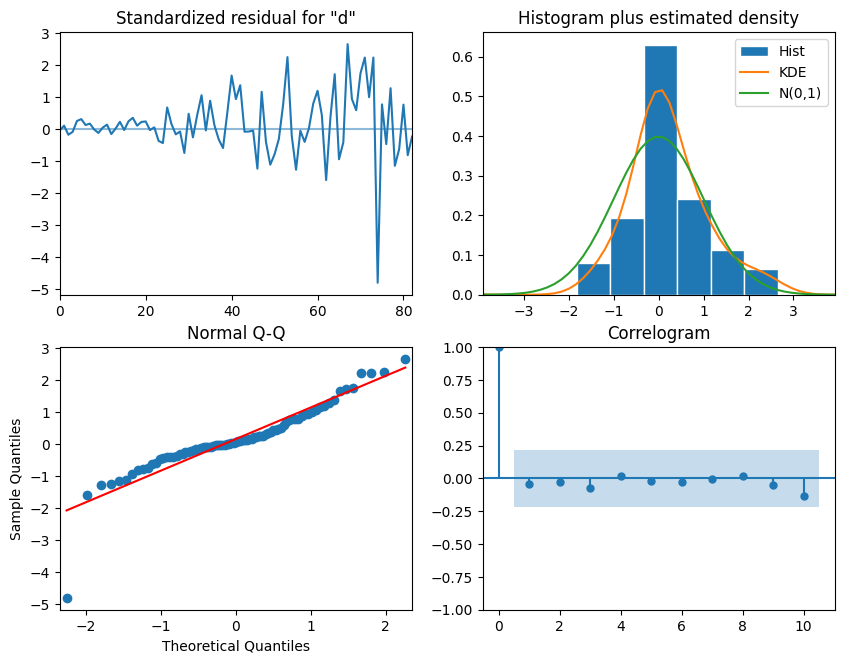

In [15]:
best_model_fit.plot_diagnostics()
plt.show()

In [16]:
test_data = data['data']

pred_start_date = test_data.index[0]
pred_end_date = test_data.index[-1]

predictions = best_model_fit.predict(start = pred_start_date, end = pred_end_date)
residulas = test_data - predictions


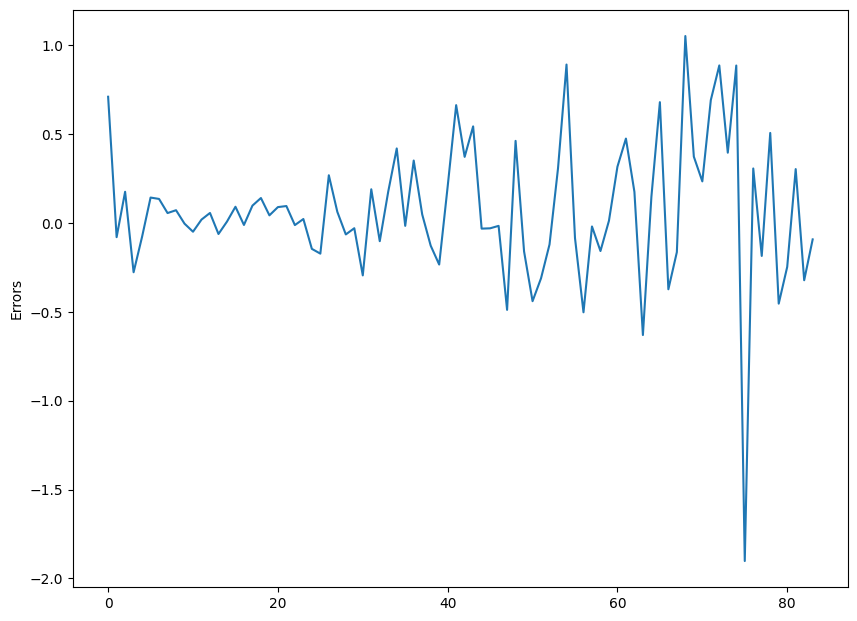

In [17]:
plt.figure()
plt.plot(residulas)
plt.ylabel('Errors')
plt.show()

In [18]:
print(f'Root Mean Squared Error:', np.sqrt(np.mean(residulas**2)))

Root Mean Squared Error: 0.4032684644240661


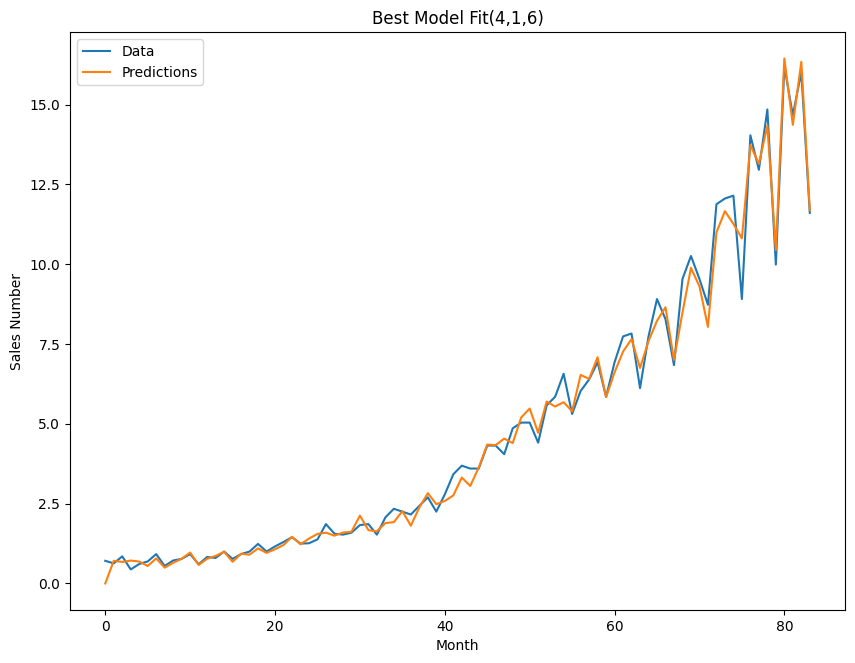

In [19]:
plt.figure()

plt.plot(test_data)
plt.plot(predictions)

plt.legend(('Data', 'Predictions'))
plt.xlabel('Month')
plt.ylabel('Sales Number')
plt.title('Best Model Fit(4,1,6)')

plt.show()

In [20]:
mape = np.mean(np.abs(predictions - test_data)/np.abs(test_data))
print(f'MAPE: {mape}')

mae = np.mean(np.abs(predictions - test_data))
print(f'MAE: {mae}')

me = np.mean(predictions - test_data)
print(f'ME: {me}')

mpe = np.mean((predictions - test_data)/ test_data)
print(f'MPE: {mpe}')

rmse = np.sqrt(np.mean((predictions - test_data)**2))
print(f'RMSE: {rmse}')



MAPE: 0.08775607163410708
MAE: 0.271962440089969
ME: -0.06955417775194397
MPE: -0.02353200281869725
RMSE: 0.4032684644240661


In [21]:
n_forecast = 24
predict = best_model_fit.get_prediction(end = model.nobs + n_forecast)
idx = np.arange(len(predict.predicted_mean))

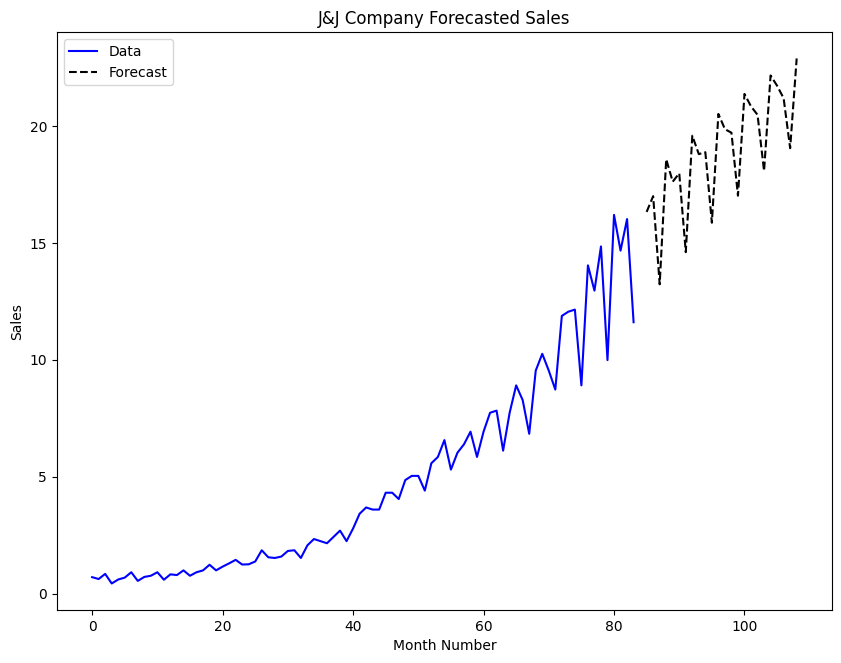

In [22]:
fig, ax= plt.subplots()
ax.plot(data['data'], 'blue')
ax.plot(idx[-n_forecast:], predict.predicted_mean[-n_forecast:], 'k--')
plt.xlabel('Month Number')
plt.ylabel('Sales')
plt.title('J&J Company Forecasted Sales')
plt.legend(('Data', 'Forecast'))

plt.show()

In [23]:
predictions_int = best_model_fit.get_forecast(steps = 24)
predictions_int.predicted_mean

,predicted_mean
84,17.446396
85,16.325547
86,16.999952
87,13.230425
88,18.575362
89,17.619888
90,17.977645
91,14.604560
92,19.584105
93,18.796429


In [24]:
predictions_int.conf_int()

,lower data,upper data
84,16.669615,18.223178
85,15.536695,17.114398
86,16.130237,17.869666
87,12.356527,14.104324
88,17.175891,19.974832
89,16.202206,19.037569
90,16.406663,19.548627
91,12.965964,16.243155
92,17.446048,21.722162
93,16.582050,21.010809


In [25]:
conf_df = pd.concat([predictions_int.predicted_mean, predictions_int.conf_int()], axis = 1)
conf_df.head()

,predicted_mean,lower data,upper data
84,17.446396,16.669615,18.223178
85,16.325547,15.536695,17.114398
86,16.999952,16.130237,17.869666
87,13.230425,12.356527,14.104324
88,18.575362,17.175891,19.974832


In [26]:
conf_df = conf_df.rename(columns = {'predicted_mean': 'Predictions', 'lower data': 'Lower CI', 'upper data': 'Upper CI'})
conf_df.head()

,Predictions,Lower CI,Upper CI
84,17.446396,16.669615,18.223178
85,16.325547,15.536695,17.114398
86,16.999952,16.130237,17.869666
87,13.230425,12.356527,14.104324
88,18.575362,17.175891,19.974832


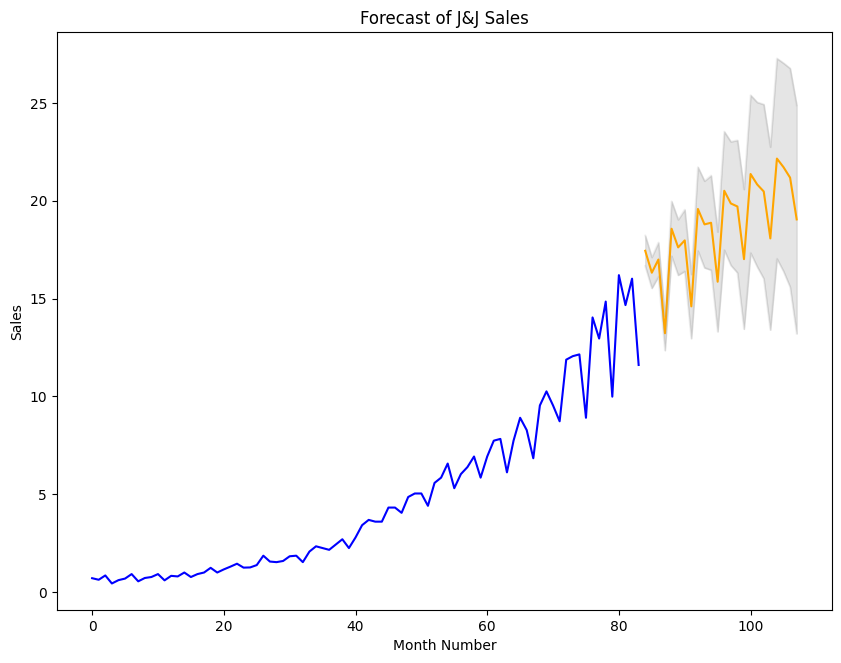

In [27]:
fig, ax = plt.subplots()
ax.plot(data['data'], 'b')

ax.set(title = 'Forecast of J&J Sales')

x = conf_df.index.values

upper = conf_df['Upper CI']
lower = conf_df['Lower CI']

conf_df['Predictions'].plot(color = 'orange', label = 'Predicted')
upper.plot(color = 'grey', label = 'Upper CI', alpha = 0.1)
lower.plot(color = 'grey', label = 'Lower CI', alpha = 0.1)

ax.fill_between(x, lower, upper, color = 'grey', alpha = 0.2)

plt.xlabel('Month Number')
plt.ylabel('Sales')

plt.show()

SARIMAX

In [28]:
#Defining test and traiin data
training_data_size = int(len(data) * 0.8)
train_data = data['data'][:training_data_size]
test_data = data['data'][training_data_size:]

In [29]:
#Getting all possible combinations
p=d=q = range(0,2)
pdq = list(product(p,d,q))
quaterly_pdq = [(x[0], x[1], x[2], 4) for x in list(product(p,d,q))]

In [30]:
params = product(p, [1], q, [1], d, quaterly_pdq)
params_list = list(params)
print(len(params_list))
params_list[0]

64


(0, 1, 0, 1, 0, (0, 0, 0, 4))

In [31]:
import tqdm.notebook

results = []
for orders in tqdm.notebook.tqdm(params_list, desc= "Optimizing SARIMAX"):
    try:
        # orders is structured as (p_val, 1, q_val, 1, d_val, (P_val, D_val, Q_val, S_val))
        # non_seasonal_order should be (orders[0], orders[4], orders[2]) based on params definition (p, [1], q, [1], d, quaterly_pdq)
        # seasonal_order should be orders[5] which is the (P,D,Q,S) tuple

        # Extracting components based on the structure of 'orders'
        p_val = orders[0]
        fixed_d1 = orders[1] # This is always 1 from the product setup
        q_val = orders[2]
        fixed_d2 = orders[3] # This is always 1 from the product setup
        d_val = orders[4] # This is the non-seasonal 'd'
        seasonal_tuple = orders[5] # This is the (P,D,Q,S) tuple

        model = SARIMAX(train_data,
                        order = (p_val, d_val, q_val),
                        seasonal_order = seasonal_tuple,
                        enforce_invertibility=False).fit()
    except Exception as e:
        # Print the error to see what's failing
        print(f"Error fitting model for order {orders}: {e}")
        continue
    results.append([orders, model.aic])

Optimizing SARIMAX:   0%|          | 0/64 [00:00<?, ?it/s]

In [32]:
#Finding lower AIC
result_df = pd.DataFrame(results)
result_df.columns = ['(p, d, q, P, D, Q, S)', 'AIC']
result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
print(result_df)

            (p, d, q, P, D, Q, S)         AIC
0   (1, 1, 1, 1, 1, (0, 1, 0, 4))   23.359925
1   (0, 1, 1, 1, 1, (0, 1, 1, 4))   23.788693
2   (0, 1, 1, 1, 1, (1, 1, 0, 4))   23.815997
3   (1, 1, 1, 1, 1, (0, 1, 1, 4))   24.217020
4   (1, 1, 1, 1, 1, (1, 1, 0, 4))   24.238699
..                            ...         ...
59  (0, 1, 0, 1, 0, (1, 0, 0, 4))  142.096748
60  (0, 1, 1, 1, 0, (0, 0, 1, 4))  233.689632
61  (0, 1, 0, 1, 0, (0, 0, 1, 4))  302.169222
62  (0, 1, 1, 1, 0, (0, 0, 0, 4))  304.354719
63  (0, 1, 0, 1, 0, (0, 0, 0, 4))  373.149961

[64 rows x 2 columns]


In [33]:
best_SARIMAX = SARIMAX(train_data, order = (1,1,1), seasonal_order=(1,1,1,4)).fit()
print(best_SARIMAX.summary())

                                     SARIMAX Results                                     
Dep. Variable:                              data   No. Observations:                   67
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 4)   Log Likelihood                  -8.099
Date:                           Fri, 03 Jul 2026   AIC                             26.197
Time:                                   19:37:17   BIC                             36.833
Sample:                                        0   HQIC                            30.373
                                            - 67                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2106      0.173      1.215      0.224      -0.129       0.550
ma.L1         -0.7841      0.121     -6.496

In [34]:
#Generate forecast equal to the length of my test data
forecast = best_SARIMAX.get_forecast(steps = len(test_data))
# DataFrame containing columns like 'mean' (the predicted values), 'mean_se' (standard error of the mean), 'mean_ci_lower', and 'mean_ci_upper' (lower and upper bounds of the confidence interval).
forecast_df = forecast.summary_frame()
# Extract the mean column from the forecast_df
pred = forecast_df['mean']
pred

,mean
67,6.891117
68,8.460706
69,9.572099
70,9.072907
71,7.640873
72,9.209410
73,10.323849
74,9.815552
75,8.386414
76,9.955014


In [35]:
mape = np.mean(np.abs(pred - test_data)/np.abs(test_data))
print(f'MAPE: {mape}')

rmse = np.sqrt(np.mean((pred - test_data)**2))
print(f'RMSE: {rmse}')

MAPE: 0.16293741929316335
RMSE: 2.6778383957683425


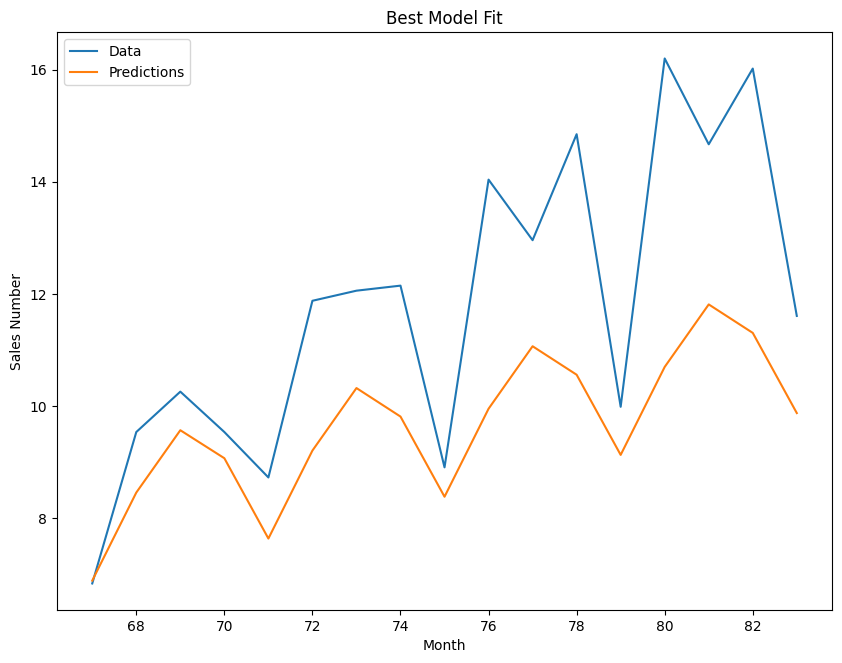

In [36]:
plt.figure()

plt.plot(test_data)
plt.plot(pred)

plt.legend(('Data', 'Predictions'))
plt.xlabel('Month')
plt.ylabel('Sales Number')
plt.title('Best Model Fit')

plt.show()

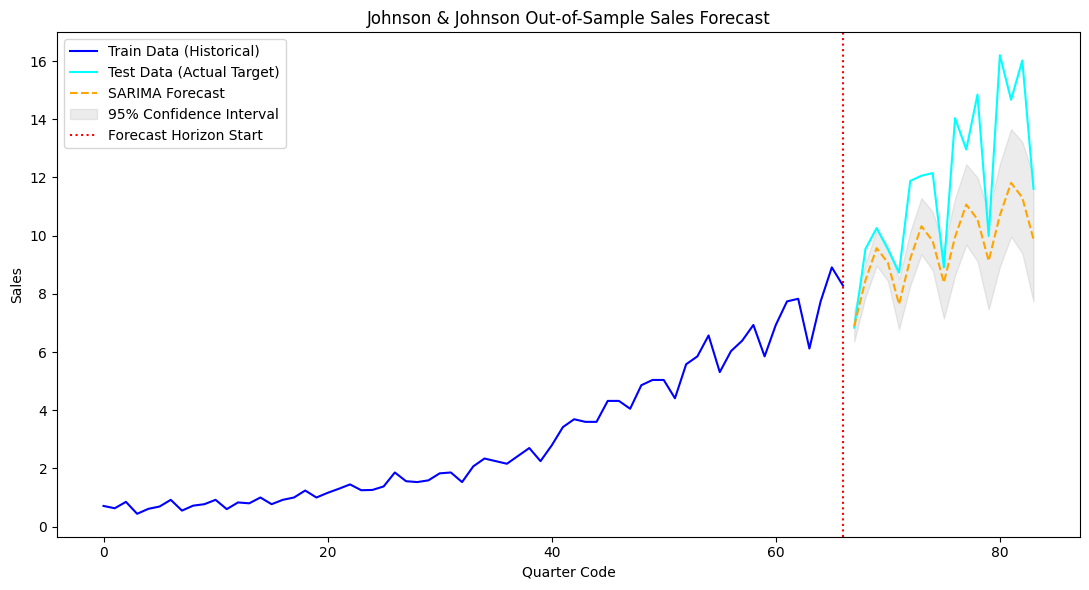

In [37]:
fig, ax = plt.subplots(figsize=(11, 6))

# Plot historical actuals and true test actuals
ax.plot(train_data.index, train_data, label='Train Data (Historical)', color='blue')
ax.plot(test_data.index, test_data, label='Test Data (Actual Target)', color='cyan')

# Plot predictions
ax.plot(test_data.index, pred, label='SARIMA Forecast', color='orange', linestyle='--')

# Plot Confidence Intervals
conf_int = forecast.conf_int()
ax.fill_between(test_data.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='gray', alpha=0.15, label='95% Confidence Interval')

# Draw a vertical line where the forecast starts
ax.axvline(x=train_data.index[-1], color='red', linestyle=':', label='Forecast Horizon Start')

plt.title('Johnson & Johnson Out-of-Sample Sales Forecast')
plt.xlabel('Quarter Code')
plt.ylabel('Sales')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()